<a href="https://colab.research.google.com/github/krishna-murari23/UGRP2026/blob/main/1DConduction_WeightsVariation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1D Heat Conduction - Steady State With Uniform Heat Generation

## Imports


In [ ]:
import autograd.numpy as np
from autograd import elementwise_grad, grad
import matplotlib.pyplot as plt

np.random.seed(0)

A rod with uniform internal heat generation obeys $\dfrac{d^2T}{dx^2} + C = 0$, where $C = \dot q/k$. Assuming a quadratic solution $T(x)=ax^2+bx+c$ lets us solve for $C$ by hand first, since $T''=2a$ for any quadratic, so $C=-2a$. With both ends at $T_0$, the exact solution is

$$T(x) = T_0 + \frac{\dot q}{2k}\,x(L-x)$$

which we can check the PINN against later.

In [ ]:
L    = 1.0      # rod length
k    = 15.0     # thermal conductivity
qdot = 3000.0   # uniform internal heat generation
T0   = 300.0    # temperature at both ends

C = qdot / k

def T_assumed(x):
    return T0 + (qdot/(2*k)) * x * (L - x)     # exact solution of this physical problem

print(f"C = {C}")
print(f"T(0) = {T_assumed(0.0)} K,  T(L) = {T_assumed(L)} K,  T(L/2) = {T_assumed(L/2)} K")

C = 200.0
T(0) = 300.0 K,  T(L) = 300.0 K,  T(L/2) = 325.0 K


We rescale $T$ into $\theta = \dfrac{T-T_0}{T_{scale}}$, i.e. $T = T_0 + T_{scale}\,\theta$ — a reversible linear change of variables, not a loss of information. Substituting into the PDE:

$$T'' + C = 0 \;\;\Longrightarrow\;\; T_{scale}\,\theta'' + C = 0 \;\;\Longrightarrow\;\; \theta'' + \underbrace{\tfrac{C}{T_{scale}}}_{C_n} = 0$$

so the network only ever has to satisfy $\theta''+C_n=0$, with $C_n\sim O(1)$ instead of $C\sim O(100)$.
tanh as an activation function is always between -1 and 1 and our weights initalised are also random, this is a poor start for physical conditions being near 300K.

In [ ]:
#Tscale = qdot * L**2 / (2*k)   # characteristic temperature rise of this rod
Tscale = qdot * L**2 / (2*k)
Cn = C * L**2 / Tscale         #  normalized units

print(f"Tscale = {Tscale} K,   Cn = {Cn}")

Tscale = 100.0 K,   Cn = 2.0


In [ ]:
x_b  = np.array([0.0, L])
Tn_b = np.array([0.0, 0.0])          # T0 maps to 0 after normalizing

N_f = 50
x_f = np.linspace(0, L, N_f)[1:-1]

In [ ]:
m = 3

def init_params(m):
    W1 = np.random.randn(m) * 1.0
    b1 = np.random.randn(m) * 1.0
    W2 = np.random.randn(m) * 1.0
    b2 = 0.0
    return (W1, b1, W2, b2)

def Tn_hat(x, params):
    W1, b1, W2, b2 = params
    h = np.tanh(np.outer(x, W1) + b1)
    return h @ W2 + b2

Differentiating the forward pass twice, reusing $h_j$ each time ($\tanh'(s)=1-h^2$):

$$\hat\theta'(x)=\sum_j W^2_j(1-h_j^2)W^1_j,\qquad \hat\theta''(x) = -2\sum_j W^2_j\,h_j(1-h_j^2)(W^1_j)^2$$

The residual is then $f(x;\theta)=\hat\theta''(x)+C_n$.

In [ ]:

dTn_dx   = elementwise_grad(Tn_hat, 0)
d2Tn_dx2 = elementwise_grad(dTn_dx, 0)

def residual(x, params):
    return d2Tn_dx2(x, params) + Cn

##  Loss function

$$\text{Loss}(\theta) = \underbrace{\frac{1}{N_b}\sum_i\big(\hat\theta(x_b^i)-\theta_b^i\big)^2}_{\text{MSE}_{bc}} \;+\; \underbrace{\frac{1}{N_f}\sum_i f(x_f^i;\theta)^2}_{\text{MSE}_f}$$

Without $\text{MSE}_f$, the trivial solution $\hat\theta\equiv0$ would satisfy $\text{MSE}_{bc}=0$ perfectly (since flat data trivially "fits" flat boundary values) while being physically wrong everywhere in between.

In [ ]:
def loss(params):
    mse_bc = np.mean((Tn_hat(x_b, params) - Tn_b) ** 2)
    mse_f  = np.mean(residual(x_f, params) ** 2)
    return mse_bc + mse_f

grad_loss = grad(loss)

### Backprop — boundary term (Job 1)

$$\text{MSE}_{bc} = \frac{1}{N_b}\sum_i \big(\hat\theta(x_b^i) - \theta_b^i\big)^2, \qquad e_i = \hat\theta(x_b^i)-\theta_b^i$$

$$\frac{\partial \text{MSE}_{bc}}{\partial W^2_j} = \frac{2}{N_b}\sum_i e_i h_{i,j}, \qquad \frac{\partial \text{MSE}_{bc}}{\partial b^2} = \frac{2}{N_b}\sum_i e_i$$

$$\frac{\partial \text{MSE}_{bc}}{\partial W^1_j} = \frac{2}{N_b}\sum_i e_i\, W^2_j(1-h_{i,j}^2)\,x_b^i, \qquad \frac{\partial \text{MSE}_{bc}}{\partial b^1_j} = \frac{2}{N_b}\sum_i e_i\, W^2_j(1-h_{i,j}^2)$$

### Backprop — PDE term (Job 2, double backprop)

$$\text{MSE}_f = \frac{1}{N_f}\sum_i f_i^2, \qquad f_i = \hat\theta''(x_f^i) + C_n, \qquad \hat\theta'' = -2\sum_j W^2_j g_j (W^1_j)^2, \qquad g_j = h_j(1-h_j^2)$$

$$\frac{\partial\text{MSE}_f}{\partial W^2_j} = \frac{2}{N_f}\sum_i f_i\cdot\big(-2\,g_{i,j}(W^1_j)^2\big), \qquad \frac{\partial\text{MSE}_f}{\partial b^2} = 0$$

$$q_j = (1-3h_j^2)(1-h_j^2)$$

$$\frac{\partial\text{MSE}_f}{\partial b^1_j} = \frac{2}{N_f}\sum_i f_i\cdot\big(-2W^2_j(W^1_j)^2\,q_{i,j}\big)$$

$$\frac{\partial\text{MSE}_f}{\partial W^1_j} = \frac{2}{N_f}\sum_i f_i\cdot\Big(-2W^2_j(W^1_j)^2\,q_{i,j}\,x_f^i -4W^2_jW^1_j\,g_{i,j}\Big)$$

### Total gradient

$$\frac{\partial L}{\partial\theta} = \frac{\partial\text{MSE}_{bc}}{\partial\theta} + \frac{\partial\text{MSE}_f}{\partial\theta}$$

## Training via GD

Plain gradient descent:

$$\theta \leftarrow \theta - \alpha\,\nabla_\theta\,\text{Loss}(\theta)$$

computed here via `grad_loss = grad(loss)`, i.e. autograd's reverse-mode differentiation of the entire loss expression above — including through the already-differentiated residual term ("double backprop").

In [ ]:
params = init_params(m)
lr = 0.1
epochs = 10000
history = []

for it in range(1, epochs + 1):
    g = grad_loss(params)
    params = tuple(p - lr*gi for p, gi in zip(params, g))
    history.append(loss(params))

print("final loss:", history[-1])

final loss: 0.0002773744136009754


## Loss curve



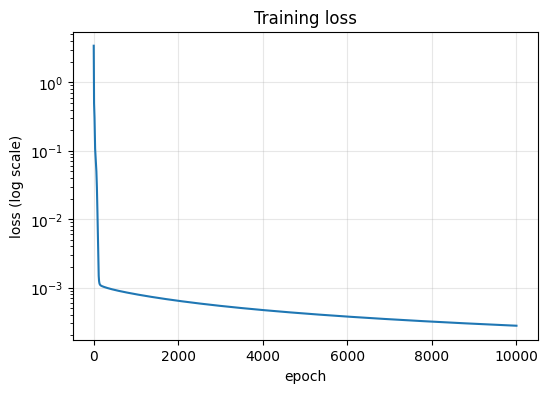

In [ ]:
plt.figure(figsize=(6,4))
plt.semilogy(history)
plt.xlabel("epoch"); plt.ylabel("loss (log scale)")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

##  Does $\hat T(x)$ match the quadratic we started with?

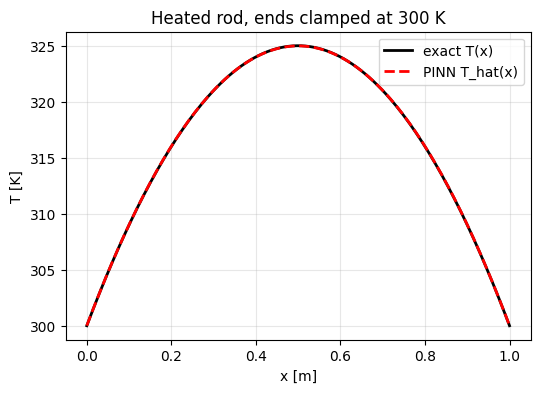

RMSE: 0.0156 K


In [ ]:
x_plot  = np.linspace(0, L, 200)
T_pinn  = Tn_hat(x_plot, params) * Tscale + T0     # back to Kelvin
T_truth = T_assumed(x_plot)

plt.figure(figsize=(6,4))
plt.plot(x_plot, T_truth, 'k-', lw=2, label="exact T(x)")
plt.plot(x_plot, T_pinn, 'r--', lw=2, label="PINN T_hat(x)")
plt.xlabel("x [m]"); plt.ylabel("T [K]")
plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Heated rod, ends clamped at 300 K")
plt.show()

rmse = np.sqrt(np.mean((T_pinn - T_truth) ** 2))
print(f"RMSE: {rmse:.4f} K")

## Does random initialization matter? Training 5 different starting points

Hypothesis to test: for the *same* physical problem (same `q`, same boundary conditions), does gradient descent always converge to the same — or very similar — final weights, no matter how the network is randomly initialized?

In [ ]:
n_trials = 5
seeds = list(range(n_trials))

def init_params_seeded(m, seed):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(m) * 1.0
    b1 = rng.randn(m) * 1.0
    W2 = rng.randn(m) * 1.0
    b2 = 0.0
    return (W1, b1, W2, b2)


## Train the same problem 5 times, from 5 different random starting points

In [ ]:
initial_params = []
final_params   = []
final_losses   = []

for seed in seeds:
    params0 = init_params_seeded(m, seed)
    params  = params0

    for it in range(1, epochs + 1):
        g = grad_loss(params)
        params = tuple(p - lr*gi for p, gi in zip(params, g))

    initial_params.append(params0)
    final_params.append(params)
    final_losses.append(loss(params))

print("done training all 5 runs")


done training all 5 runs


## Print initial vs. final weights for each run

In [ ]:
for i, seed in enumerate(seeds):
    W1_0, b1_0, W2_0, b2_0 = initial_params[i]
    W1_f, b1_f, W2_f, b2_f = final_params[i]
    print(f"\n--- seed {seed} ---")
    print(f"initial:  W1={W1_0}  b1={b1_0}  W2={W2_0}  b2={b2_0}")
    print(f"final  :  W1={W1_f}  b1={b1_f}  W2={W2_f}  b2={b2_f}")
    print(f"final loss: {final_losses[i]:.6e}")



--- seed 0 ---
initial:  W1=[1.76405235 0.40015721 0.97873798]  b1=[ 2.2408932   1.86755799 -0.97727788]  W2=[ 0.95008842 -0.15135721 -0.10321885]  b2=0.0
final  :  W1=[1.21144915 0.16893935 1.21931712]  b1=[ 0.62656057  2.0127648  -1.84762203]  W2=[ 1.39708901 -1.07155199 -1.3710181 ]  b2=-1.0468614646783103
final loss: 2.773744e-04

--- seed 1 ---
initial:  W1=[ 1.62434536 -0.61175641 -0.52817175]  b1=[-1.07296862  0.86540763 -2.3015387 ]  W2=[ 1.74481176 -0.7612069   0.3190391 ]  b2=0.0
final  :  W1=[ 1.12693378  1.14765443 -0.36002546]  b1=[ 0.66803688 -1.80201334 -2.36661667]  W2=[ 1.59869995 -1.50152765  1.31042334]  b2=-1.0645831548750515
final loss: 1.250921e-03

--- seed 2 ---
initial:  W1=[-0.41675785 -0.05626683 -2.1361961 ]  b1=[ 1.64027081 -1.79343559 -0.84174737]  W2=[ 0.50288142 -1.24528809 -1.05795222]  b2=0.0
final  :  W1=[-1.19302635  0.09398655 -1.19744342]  b1=[ 1.8277165  -1.69434168 -0.63458332]  W2=[ 1.43190116  0.39091354 -1.41719289]  b2=-1.789631893698016
fin

## Are the weights actually similar across runs?

A quick way to check: measure how spread out the final `W1` values are, run to run.

In [ ]:
W1_finals = np.array([p[0] for p in final_params])   # shape (n_trials, m)
print("final W1 across all 5 seeds:\n", W1_finals)
print("\nstd. dev. of W1 across seeds (per neuron):", W1_finals.std(axis=0))


final W1 across all 5 seeds:
 [[ 1.21144915  0.16893935  1.21931712]
 [ 1.12693378  1.14765443 -0.36002546]
 [-1.19302635  0.09398655 -1.19744342]
 [ 1.20165541  0.06666965  1.22177085]
 [ 1.17314366  1.13760685 -0.54730691]]

std. dev. of W1 across seeds (per neuron): [0.94898296 0.50706678 0.98182188]


## The weights don't match — but does the *function* they compute match?

A tanh network has symmetries that let very different-looking weights compute the exact same output:
- **Neuron swap:** relabeling neuron 1 ↔ neuron 3 changes $W^1,b^1,W^2$ but not $\hat\theta(x)$.
- **Sign flip:** since $\tanh$ is odd, flipping the sign of $W^1_j,\,b^1_j,\,W^2_j$ together for one neuron leaves that neuron's contribution unchanged.

So the fairer test isn't "do the weights match" but "does the curve match."

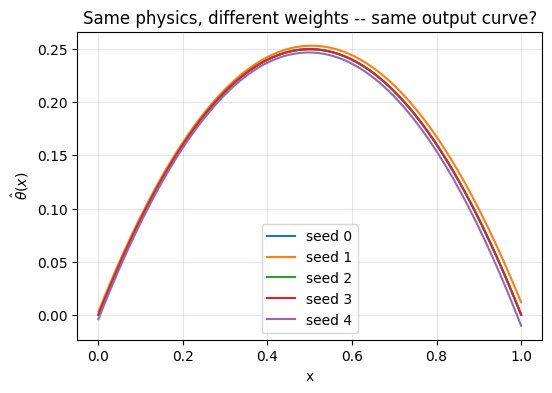

In [ ]:
x_check = np.linspace(0, L, 200)
curves = [Tn_hat(x_check, p) for p in final_params]

plt.figure(figsize=(6,4))
for seed, curve in zip(seeds, curves):
    plt.plot(x_check, curve, label=f"seed {seed}")
plt.xlabel("x"); plt.ylabel(r"$\hat\theta(x)$")
plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Same physics, different weights -- same output curve?")
plt.show()


In [ ]:
ref = curves[0]
for seed, curve in zip(seeds, curves):
    diff = np.sqrt(np.mean((curve - ref)**2))
    print(f"seed {seed}: RMSE vs seed 0's curve = {diff:.6f}")


seed 0: RMSE vs seed 0's curve = 0.000000
seed 1: RMSE vs seed 0's curve = 0.005358
seed 2: RMSE vs seed 0's curve = 0.000013
seed 3: RMSE vs seed 0's curve = 0.000033
seed 4: RMSE vs seed 0's curve = 0.005145


## Conclusion

- **The hypothesis is false at the level of individual weights.** Different random
  initializations converge to clearly different $(W^1,b^1,W^2,b^2)$ — not close at all.
- **But the function each network computes converges reliably.** The five output
  curves overlap almost exactly, because the small differences in weights are mostly
  just neuron-swap / sign-flip symmetries that don't change $\hat\theta(x)$ itself.
- Takeaway: for a small network fitting a simple target, there are many different
  weight configurations that all represent (nearly) the same function — training is
  reliable in *function space*, not in *weight space*.